In [1]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: Tesla T4


In [ ]:
from pathlib import Path

PROJECT_ROOT = Path.cwd()

if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

print("Project root:", PROJECT_ROOT)

/content/CV-P22-building-segmentation


In [ ]:
import sys
import segmentation_models_pytorch as smp

sys.path.append(str(PROJECT_ROOT))

from src.preprocessing import load_and_preprocess

In [29]:
import pandas as pd

SPLITS_DIR = PROJECT_ROOT / "data" / "splits"

train_df = pd.read_csv(SPLITS_DIR / "train.csv")
val_df = pd.read_csv(SPLITS_DIR / "val.csv")
test_df = pd.read_csv(SPLITS_DIR / "test.csv")

print(len(train_df))
print(len(val_df))
print(len(test_df))

4932
144
360


In [ ]:
import random
import numpy as np
import torch

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("Random seed:", SEED)

In [30]:
from torch.utils.data import Dataset, DataLoader


class BuildingDataset(Dataset):
    def __init__(self, dataframe, project_root):
        self.dataframe = dataframe.reset_index(drop=True)
        self.project_root = project_root

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        image_path = self.project_root / row["image_path"]
        mask_path = self.project_root / row["mask_path"]

        image, mask = load_and_preprocess(
            image_path,
            mask_path
        )

        return image, mask

In [31]:
train_dataset = BuildingDataset(train_df, PROJECT_ROOT)
val_dataset = BuildingDataset(val_df, PROJECT_ROOT)
test_dataset = BuildingDataset(test_df, PROJECT_ROOT)

In [ ]:
BATCH_SIZE = 8

generator = torch.Generator()
generator.manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
    generator=generator

)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

In [41]:
images, masks = next(iter(train_loader))

print(images.shape)
print(masks.shape)

torch.Size([8, 3, 256, 256])
torch.Size([8, 1, 256, 256])


In [42]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

Device: cuda


In [43]:
model = smp.Unet(
    encoder_name="resnet18",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1
)

model = model.to(device)

In [44]:
images, masks = next(iter(train_loader))

images = images.to(device)
masks = masks.to(device)

with torch.no_grad():
    outputs = model(images)

print("Images:", images.shape)
print("Masks:", masks.shape)
print("Outputs:", outputs.shape)

Images: torch.Size([8, 3, 256, 256])
Masks: torch.Size([8, 1, 256, 256])
Outputs: torch.Size([8, 1, 256, 256])


In [45]:
from tqdm.auto import tqdm
import pandas as pd
import torch


# Loss and optimizer
criterion = torch.nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)


def compute_segmentation_stats(logits, targets, threshold=0.5):
    probabilities = torch.sigmoid(logits)
    predictions = (probabilities >= threshold).float()

    intersection = (predictions * targets).sum().item()

    prediction_sum = predictions.sum().item()
    target_sum = targets.sum().item()

    union = prediction_sum + target_sum - intersection

    return intersection, union, prediction_sum, target_sum


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    total_loss = 0.0

    total_intersection = 0.0
    total_union = 0.0
    total_prediction_sum = 0.0
    total_target_sum = 0.0

    progress_bar = tqdm(loader, desc="Training", leave=False)

    for images, masks in progress_bar:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, masks)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)

        intersection, union, pred_sum, target_sum = (
            compute_segmentation_stats(
                outputs.detach(),
                masks
            )
        )

        total_intersection += intersection
        total_union += union
        total_prediction_sum += pred_sum
        total_target_sum += target_sum

        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    average_loss = total_loss / len(loader.dataset)

    iou = (
        total_intersection
        / (total_union + 1e-7)
    )

    dice = (
        2 * total_intersection
        / (
            total_prediction_sum
            + total_target_sum
            + 1e-7
        )
    )

    return average_loss, iou, dice


def evaluate(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0

    total_intersection = 0.0
    total_union = 0.0
    total_prediction_sum = 0.0
    total_target_sum = 0.0

    progress_bar = tqdm(loader, desc="Validation", leave=False)

    with torch.no_grad():
        for images, masks in progress_bar:
            images = images.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, masks)

            total_loss += loss.item() * images.size(0)

            intersection, union, pred_sum, target_sum = (
                compute_segmentation_stats(
                    outputs,
                    masks
                )
            )

            total_intersection += intersection
            total_union += union
            total_prediction_sum += pred_sum
            total_target_sum += target_sum

    average_loss = total_loss / len(loader.dataset)

    iou = (
        total_intersection
        / (total_union + 1e-7)
    )

    dice = (
        2 * total_intersection
        / (
            total_prediction_sum
            + total_target_sum
            + 1e-7
        )
    )

    return average_loss, iou, dice


# Training settings
NUM_EPOCHS = 10

history = []

best_val_loss = float("inf")

MODEL_PATH = (
    PROJECT_ROOT
    / "results"
    / "baseline_unet_resnet18.pt"
)

METRICS_DIR = (
    PROJECT_ROOT
    / "results"
    / "metrics"
)

MODEL_PATH.parent.mkdir(
    parents=True,
    exist_ok=True
)

METRICS_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# Training loop
for epoch in range(1, NUM_EPOCHS + 1):

    print(f"\nEpoch {epoch}/{NUM_EPOCHS}")

    train_loss, train_iou, train_dice = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_iou, val_dice = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_iou": train_iou,
        "train_dice": train_dice,
        "val_loss": val_loss,
        "val_iou": val_iou,
        "val_dice": val_dice,
    })

    print(
        f"Train loss: {train_loss:.4f} | "
        f"Train IoU: {train_iou:.4f} | "
        f"Train Dice: {train_dice:.4f}"
    )

    print(
        f"Val loss:   {val_loss:.4f} | "
        f"Val IoU:   {val_iou:.4f} | "
        f"Val Dice:  {val_dice:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss

        torch.save(
            model.state_dict(),
            MODEL_PATH
        )

        print("Best checkpoint saved.")


# Save training history
history_df = pd.DataFrame(history)

history_df.to_csv(
    METRICS_DIR / "baseline_training_history.csv",
    index=False
)

print("\nTraining finished.")
print("Best validation loss:", round(best_val_loss, 4))
print("Best model saved to:", MODEL_PATH)

history_df


Epoch 1/10


Training:   0%|          | 0/617 [00:00<?, ?it/s]

Validation:   0%|          | 0/18 [00:00<?, ?it/s]

Train loss: 0.2175 | Train IoU: 0.4443 | Train Dice: 0.6152
Val loss:   0.2045 | Val IoU:   0.4709 | Val Dice:  0.6403
Best checkpoint saved.

Epoch 2/10


Training:   0%|          | 0/617 [00:00<?, ?it/s]

...

Train loss: 0.1452 | Train IoU: 0.6113 | Train Dice: 0.7588
Val loss:   0.1290 | Val IoU:   0.6080 | Val Dice:  0.7562

Epoch 10/10


Training:   0%|          | 0/617 [00:00<?, ?it/s]

Validation:   0%|          | 0/18 [00:00<?, ?it/s]

Train loss: 0.1405 | Train IoU: 0.6222 | Train Dice: 0.7671
Val loss:   0.1181 | Val IoU:   0.6338 | Val Dice:  0.7759
Best checkpoint saved.

Training finished.
Best validation loss: 0.1181
Best model saved to: /content/CV-P22-building-segmentation/results/baseline_unet_resnet18.pt


,epoch,train_loss,train_iou,train_dice,val_loss,val_iou,val_dice
0,1,0.217457,0.444278,0.615225,0.204477,0.470871,0.640261
1,2,0.180686,0.523357,0.687110,0.151757,0.507126,0.672971
2,3,0.169537,0.553006,0.712175,0.139591,0.571108,0.727013
3,4,0.162445,0.569304,0.725550,0.136246,0.565671,0.722592
4,5,0.156892,0.580525,0.734598,0.132099,0.595096,0.746157
5,6,0.153982,0.589908,0.742066,0.119634,0.607184,0.755588
6,7,0.151749,0.595861,0.746758,0.122214,0.604474,0.753486
7,8,0.147428,0.606908,0.755374,0.131711,0.594164,0.745424
8,9,0.145157,0.611344,0.758800,0.128951,0.608015,0.756230
9,10,0.140535,0.622156,0.767073,0.118054,0.633801,0.775860


In [46]:
model.load_state_dict(
    torch.load(
        MODEL_PATH,
        map_location=device
    )
)

model = model.to(device)
model.eval()

print("Best checkpoint loaded.")

Best checkpoint loaded.


In [47]:
test_loss, test_iou, test_dice = evaluate(
    model,
    test_loader,
    criterion,
    device
)

print(f"Test loss: {test_loss:.4f}")
print(f"Test IoU:  {test_iou:.4f}")
print(f"Test Dice: {test_dice:.4f}")

Validation:   0%|          | 0/45 [00:00<?, ?it/s]

Test loss: 0.1597
Test IoU:  0.6898
Test Dice: 0.8164


In [48]:
best_epoch_row = history_df.loc[
    history_df["val_loss"].idxmin()
]

baseline_metrics = pd.DataFrame([
    {
        "model": "U-Net + ResNet18",
        "encoder_weights": "ImageNet",
        "loss": "BCEWithLogitsLoss",
        "optimizer": "Adam",
        "learning_rate": 1e-3,
        "threshold": 0.5,
        "best_epoch": int(best_epoch_row["epoch"]),
        "best_val_loss": best_epoch_row["val_loss"],
        "best_val_iou": best_epoch_row["val_iou"],
        "best_val_dice": best_epoch_row["val_dice"],
        "test_loss": test_loss,
        "test_iou": test_iou,
        "test_dice": test_dice,
    }
])

baseline_metrics.to_csv(
    METRICS_DIR / "baseline_metrics.csv",
    index=False
)

baseline_metrics

,model,encoder_weights,loss,optimizer,learning_rate,threshold,best_epoch,best_val_loss,best_val_iou,best_val_dice,test_loss,test_iou,test_dice
0,U-Net + ResNet18,ImageNet,BCEWithLogitsLoss,Adam,0.001,0.5,10,0.118054,0.633801,0.77586,0.159672,0.689807,0.816433


In [50]:
images, masks = next(iter(test_loader))

images_device = images.to(device)

with torch.no_grad():
    logits = model(images_device)

probabilities = torch.sigmoid(logits)
predictions = (probabilities >= 0.5).float().cpu()

print("Images:", images.shape)
print("Ground truth:", masks.shape)
print("Predictions:", predictions.shape)

Images: torch.Size([8, 3, 256, 256])
Ground truth: torch.Size([8, 1, 256, 256])
Predictions: torch.Size([8, 1, 256, 256])


In [52]:
IMAGENET_MEAN_TENSOR = torch.tensor(
    [0.485, 0.456, 0.406]
).view(3, 1, 1)

IMAGENET_STD_TENSOR = torch.tensor(
    [0.229, 0.224, 0.225]
).view(3, 1, 1)


def denormalize_image(image):
    image = image.cpu()

    image = (
        image * IMAGENET_STD_TENSOR
        + IMAGENET_MEAN_TENSOR
    )

    return image.clamp(0, 1)

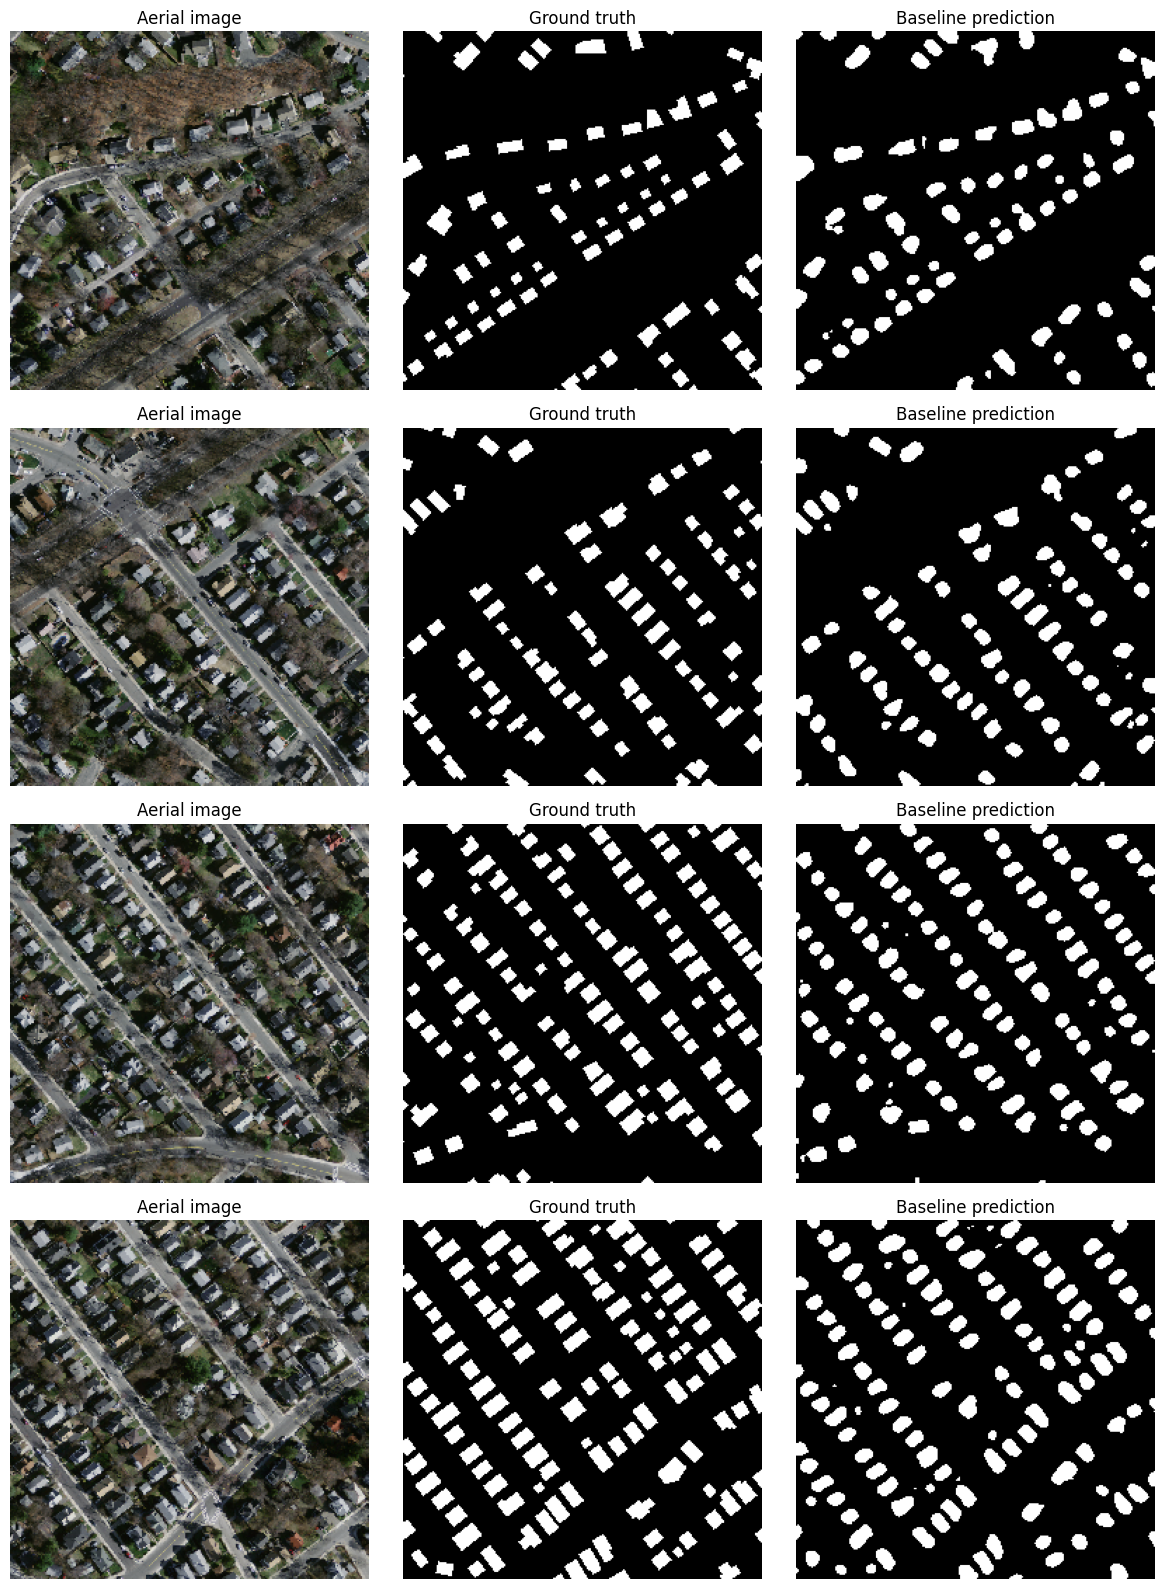

In [53]:
import matplotlib.pyplot as plt

NUM_EXAMPLES = 4

fig, axes = plt.subplots(
    NUM_EXAMPLES,
    3,
    figsize=(12, 4 * NUM_EXAMPLES)
)

for i in range(NUM_EXAMPLES):
    image = denormalize_image(images[i])
    image = image.permute(1, 2, 0).numpy()

    ground_truth = masks[i, 0].numpy()
    prediction = predictions[i, 0].numpy()

    axes[i, 0].imshow(image)
    axes[i, 0].set_title("Aerial image")

    axes[i, 1].imshow(ground_truth, cmap="gray")
    axes[i, 1].set_title("Ground truth")

    axes[i, 2].imshow(prediction, cmap="gray")
    axes[i, 2].set_title("Baseline prediction")

    for ax in axes[i]:
        ax.axis("off")

plt.tight_layout()
plt.show()

In [54]:
from PIL import Image
import numpy as np

PREDICTIONS_DIR = (
    PROJECT_ROOT
    / "results"
    / "predictions"
)

PREDICTIONS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

for i in range(min(10, len(predictions))):
    prediction = predictions[i, 0].numpy()

    prediction_image = (
        prediction * 255
    ).astype(np.uint8)

    Image.fromarray(prediction_image).save(
        PREDICTIONS_DIR
        / f"baseline_prediction_{i:02d}.png"
    )

print("Predictions saved.")

Predictions saved.
